# Inicialización

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd

In [3]:
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]= False

In [4]:
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [5]:
f = '../examples/reactions_autocat.txt'
reactions = read_file(f)
species = obtain_species(reactions)

In [6]:
def plot(abundances, times, V, SPECIES):
    colors = plt.get_cmap('Set2').colors
    colors = colors

    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(7,5)) 

    # --- Subplot 1: Concentration ---
    ax1 = axes[0]
    for i in range(len(SPECIES)):
        # Calculate concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=SPECIES[i], color=colors[i], alpha=0.9, linewidth= 2)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time", fontsize= label_fs)
    ax1.set_ylabel("Concentration", fontsize= label_fs)
    ax1.set_title("Concentration Evolution", fontsize= title_fs)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="SPECIES", fontsize= legend_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)

    # --- Subplot 2: Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray',alpha=0.9,linewidth= 2)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize= label_fs)
    ax2.set_ylabel("Volume", fontsize= label_fs)
    ax2.set_title("Volume Evolution", fontsize= title_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)
   
    plt.tight_layout(rect=[0, 0, 1, 1]) 
    plt.show()

In [7]:
def load_streamed_pickle(filename):
    data = {}
    try:
        with open(filename, "rb") as file:
            while True:
                try:
                    # Load one object (which is a dict of {k_i: (abundances, times, volumes)})
                    chunk = pickle.load(file)
                    # Merge the loaded chunk into the main dictionary
                    data.update(chunk)
                except EOFError:
                    # Reached the end of the file
                    break
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    
    print(f"Successfully loaded {len(data)} simulation results.")
    return data

In [8]:
def get_alpha_single_run(cond:float, result:tuple, values_used = None):
    _, times, volumes = result
        
    times = np.array(times)
    volumes = np.array(volumes)
    
    # Use data points from index len/5 onwards
    if values_used == None:
        start_idx = round(len(volumes) / 5)
        log_v = np.log(volumes[start_idx:])
        t_subset = times[start_idx:]
    
    else:
        values_used = round(len(volumes) * values_used)
        log_v = np.log(volumes[:values_used])
        t_subset = times[:values_used]
    
    # Perform linear regression
    # polyfit(x, y, 1) returns [slope, intercept]
    coefficients = np.polyfit(t_subset, log_v, 1)
    m_fit = coefficients[0]      # This is alpha (slope)
    log_A_fit = coefficients[1]  # This is the intercept
    A_fit = np.exp(log_A_fit)
    
    # --- R-SQUARED CALCULATION ---
    log_v_predicted = log_A_fit + m_fit * t_subset
    log_v_mean = np.mean(log_v)
    SS_res = np.sum((log_v - log_v_predicted)**2)
    SS_tot = np.sum((log_v - log_v_mean)**2)
    R_squared = 1 - (SS_res / SS_tot) if SS_tot != 0 else 0
    
    
    rmse = np.sqrt(SS_res / len(volumes)) if len(volumes) > 0 else 0
    
    # Return a dictionary directly
    return {
        'Condition': cond,
        'Alpha': m_fit,
        'Scaling Const. (A)': A_fit,
        'R^2': R_squared,
        'RMSE': rmse
    }

In [9]:
def plot_all_volumes_AB(results: dict, xlim= None, ylim= None, lim= None, rep= 0, fig_name= None):
    if lim != None:
        filtered_conditions = [c for c in results.keys() if float(c) < lim[1]]

        filtered_conditions = [c for c in filtered_conditions if float(c) > lim[0]]

    else:
        filtered_conditions = results
        
    # Update the color gradient length
    color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))
    plt.figure(figsize=(4,3.7))
    # Then loop through filtered_conditions instead of results.items()
    for j, condition in enumerate(filtered_conditions):
        replicates = results[condition]
              
        if not isinstance(replicates, tuple):
            # for rep in replicates:
            if isinstance(replicates[rep], dict):
                data_tuple = list(replicates[rep].values())[0]
            else:
                data_tuple = replicates[rep]
            a, t, v = data_tuple
            # print(fr"For simulation $k_{i}$ = {condition}") 
            # print(fr"-  Highest volume = {max(v)}")
            # print(fr"-  Lowest volume = {min(v)}")
            plt.plot(t, v, color=color_gradient[j], label=condition, alpha = 0.9, linewidth= 2)    

    plt.legend(title = rf"Value of $[AB]_0$", fontsize= legend_fs,
            loc='center left', bbox_to_anchor=(1.05, 0.5), title_fontsize= title_fs)
    if xlim != None:
        plt.xlim((0,xlim))

    if ylim!= None:
        plt.ylim(ylim)
    
    import matplotlib.ticker as ticker
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    plt.yscale('log')
    plt.xlabel("Time", fontsize = label_fs)
    plt.ylabel("Volume", fontsize = label_fs)
    plt.axhline(y= v[0]*2, color= 'darkgray', alpha= 0.6, linestyle=":")
    plt.tick_params(axis='both', labelsize= tick_fs)
    if fig_name != None:
        plt.savefig(f"../figures_TFM/{fig_name}.png")
    plt.show()



In [10]:
def identify_reaction_history(abundance_matrix, c_matrix):
    """
    abundance_matrix: (Steps x Species) matrix of counts
    c_matrix: (Reactions x Species) stoichiometry matrix
    """
    # 1. Calculate the change in molecules between each time step
    # diffs will have shape (Steps-1, Species)
    # eliminamos food species: no cambian según la matriz c
    diffs = np.diff(abundance_matrix, axis=0)[:, 4:]
    c_matrix = c_matrix[:, 4:]
    reaction_history = []
    
    # 2. Match each row of diffs to a row in c_matrix
    for delta in diffs:
        # Check which row in C is equal to the delta
        # We use np.all(..., axis=1) to check all species at once
        matches = np.where((c_matrix == delta).all(axis=1))[0]
        
        if len(matches) > 0:
            # Append the index of the matching reaction
            reaction_history.append(matches[0])
        else:
            # This handles cases where no change occurred (if your code allows that)
            reaction_history.append(None) 
            
    return np.array(reaction_history)

def plot_reaction_timeline(times, reaction_labels, a):
    reaction_history=identify_reaction_history(a, c_matrix(read_file(f),species, get_header(f)))
    
    plt.figure(figsize=(7, 3))
    
    # Plotting the events
    # Ensure reaction_history is filtered for None values if any remain
    plt.scatter(times[1:], reaction_history, marker='|', s=100, color='firebrick')
    
    # Reverse the Y-axis so 0 is at the top
    plt.gca().invert_yaxis()
    
    # Formatting
    plt.yticks(range(len(reaction_labels)), reaction_labels)
    plt.tick_params(axis='both', labelsize=tick_fs)
    plt.xlabel("Time", fontsize=label_fs)
    plt.ylabel("Reaction", fontsize=label_fs)
    plt.title("Reaction Event Timeline", fontsize=title_fs)
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [11]:

def plot_AB_barrido(results, fig_name= None):
    if 0.0 in results:
        results.pop(0.0)
    stats_results = []

    for condition, replicates in results.items():
        alphas = []
        r2_values = []
        if not isinstance(replicates, tuple):
            for rep in replicates:
                # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
                if isinstance(rep, dict):
                    # This gets the first value in the dict, which is your (ab, t, v) tuple
                    data_tuple = list(rep.values())[0]
                else:
                    data_tuple = rep
                    
                res = get_alpha_single_run(condition, data_tuple, values_used= 1) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
        else:
            res = get_alpha_single_run(condition, replicates, values_used= 1) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
        
        stats_results.append({
            'Condition': condition,
            'Alpha_mean': np.mean(alphas),
            'Alpha_std': np.std(alphas),
            'R2_mean': np.mean(r2_values)
        })

    # Convert to DataFrame or Sortable List for plotting
    stats_results = pd.DataFrame(stats_results).sort_values('Condition')
    print(stats_results)

    # Plotting with Error Bars
    fig, ax1 = plt.subplots(figsize= (4,3.7))

    # Primary Axis: Alpha with Error Bars
    ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize= label_fs) 
    ax1.set_ylabel(r'$\alpha$', color="teal", fontsize= label_fs)

    ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
                yerr=stats_results['Alpha_std'], color="teal", capsize=4, label=r'Mean $\alpha$')

    ax1.tick_params(axis='y', labelcolor="teal", labelsize= tick_fs)
    ax1.grid(True, linestyle=':', alpha=0.5, which='both')
    ax1.axhline(y=0, color="teal", alpha=0.6, linestyle=":")
    # ax1.set_xscale('log')
    ax1.tick_params(axis='x', labelsize=tick_fs)  

    # Secondary Axis: R^2
    ax2 = ax1.twinx()  
    ax2.set_ylabel(r'$R^2$', color="orangered", fontsize= label_fs)  
    ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
                color="orangered", marker='s', alpha=0.6)

    ax2.tick_params(axis='y', labelcolor="orangered", labelsize= tick_fs)
    ax2.set_ylim((0, 1.05))
    # ax2.set_xscale('log')
    ax2.tick_params(axis='x', labelsize=tick_fs)  
    fig.tight_layout()
    if fig_name != None:
        plt.savefig(f"../figures_TFM/{fig_name}.png")
    plt.show()


# barrido

Successfully loaded 32 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
8         0.5    0.744173        0.0  0.999932
9         1.0    0.499308        0.0  0.999868
10        1.5    0.253531        0.0  0.999114
12        2.0    0.002533        0.0  0.417743
13        2.5   -0.151725        0.0  0.951117
14        3.0   -0.291659        0.0  0.922460
15        3.5   -0.452218        0.0  0.934375
16        4.0   -0.777225        0.0  0.941523
17        4.5   -0.849926        0.0  0.958390
18        5.0   -0.865633        0.0  0.968414
19        5.5   -0.892668        0.0  0.977327
20        6.0   -1.061821        0.0  0.978233
21        6.5   -0.846737        0.0  0.986630
22        7.0   -0.871635        0.0  0.981289
23        7.5   -0.992858        0.0  0.987461
24        8.0   -0.968142        0.0  0.956469
25        8.5   -0.810312        0.0  0.993677
26        9.0   -0.865732        0.0  0.991850
27        9.5   -0.964061        0.0  0.990882
28       10.0   -

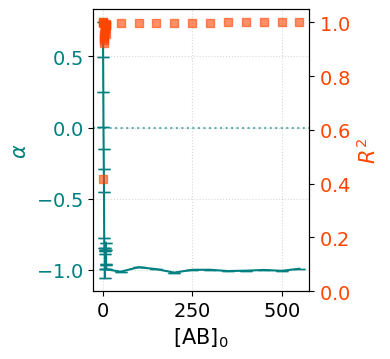

   Condition  Alpha_mean  Alpha_std   R2_mean
0        0.5    0.744173        0.0  0.999932
1        1.0    0.499308        0.0  0.999868
2        1.5    0.253531        0.0  0.999114
3        2.0    0.002533        0.0  0.417743
4        2.5   -0.151725        0.0  0.951117
5        3.0   -0.291659        0.0  0.922460
6        3.5   -0.452218        0.0  0.934375
7        4.0   -0.777225        0.0  0.941523
8        4.5   -0.849926        0.0  0.958390


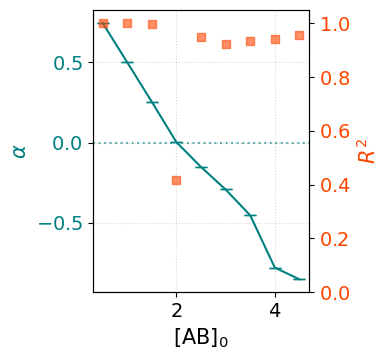

In [19]:
results = load_streamed_pickle("barrido_ab0_third_order.pkl")
plot_AB_barrido(results)
for el in np.linspace(50, 1000, 20):
    if el in results:
        results.pop(el)
for el in np.linspace(5, 10, 11):
    if el in results:
        results.pop(el)
plot_AB_barrido(results)

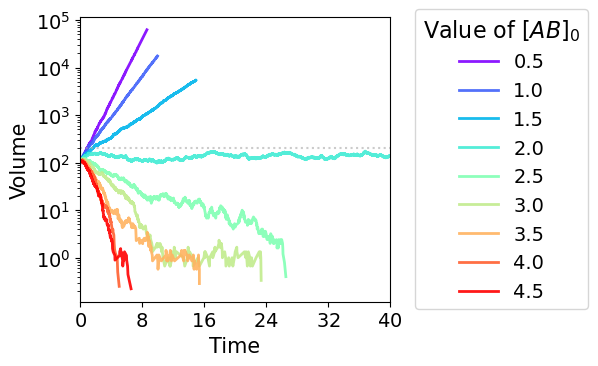

In [20]:
plot_all_volumes_AB(results, xlim= 40)

In [18]:
print(np.linspace(5,10, 11))

[ 5.   5.5  6.   6.5  7.   7.5  8.   8.5  9.   9.5 10. ]


# mm

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         5.0    0.298470        0.0  0.999974
1        10.0    0.298108        0.0  0.999953
2        15.0    0.303643        0.0  0.999941
3        20.0    0.301142        0.0  0.999919
4        25.0    0.303003        0.0  0.999913
5        30.0    0.301247        0.0  0.999847
6        35.0    0.303330        0.0  0.999813
7        40.0    0.301562        0.0  0.999829
8        45.0    0.299740        0.0  0.999774
9        50.0    0.304391        0.0  0.999809
10       55.0    0.300507        0.0  0.999751
11       60.0    0.297907        0.0  0.999755
12       65.0    0.300988        0.0  0.999695
13       70.0    0.296856        0.0  0.999685
14       75.0    0.300985        0.0  0.999444
15       80.0    0.298183        0.0  0.999595
16       85.0    0.296985        0.0  0.999372
17       90.0    0.298974        0.0  0.999303
18       95.0    0.295527        0.0  0.999139
19      100.0    

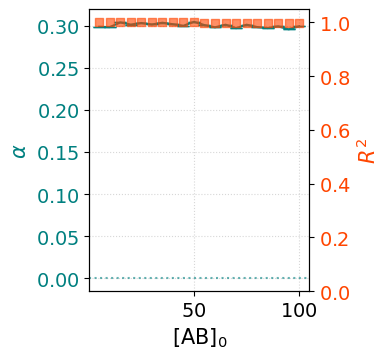

In [18]:
results = load_streamed_pickle("barrido_ab0_MM_v2.pkl")
plot_AB_barrido(results)




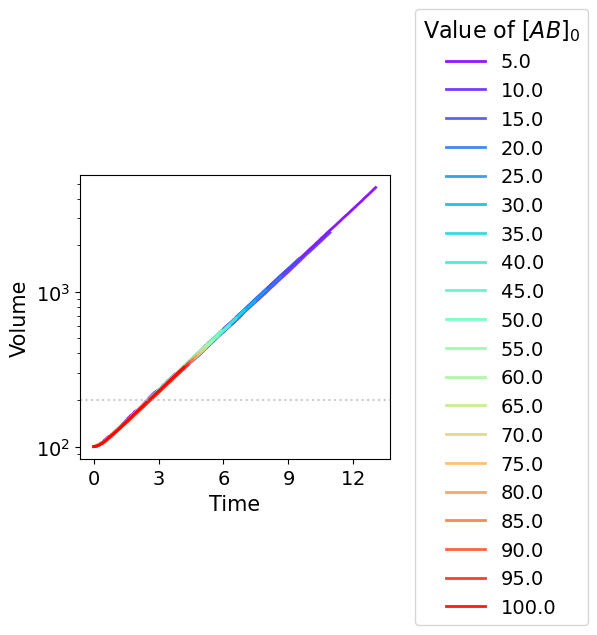

In [19]:
plot_all_volumes_AB(results,  )

In [14]:
for i in results.keys():
    print(i)
    a, t, v = results[i][0]  # Get the first replicate's data tuple
    plot()

50.0


TypeError: plot() missing 4 required positional arguments: 'abundances', 'times', 'V', and 'SPECIES'